# LIBERO demo-0 gripper diffusion forensics

This notebook diagnoses why one-call teacher-forced denoising reports perfect release accuracy while sequential diffusion sampling does not. It checks labels, phase masks, prefix-4 execution metrics, raw-score threshold separability, every clean-x0 prediction on the actual solver path, the pre-override solver result, and dependence on forward-noised ground-truth motion tokens.

In [1]:
import os, sys, json, gc
from pathlib import Path
from types import MethodType
os.environ.setdefault('MUJOCO_GL', 'egl')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/thinkflow-cache')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/thinkflow-matplotlib')

def find_repo_root(start):
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists(): return candidate
    raise RuntimeError('Start Jupyter inside ThinkFlow-RDT-1B')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
for path in (REPO_ROOT, REPO_ROOT / 'src', REPO_ROOT / 'scripts'):
    if str(path) not in sys.path: sys.path.insert(0, str(path))
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display
from thinkflow_rdt.adapters.libero import rdt_action_to_libero
print('Repository:', REPO_ROOT)
print('Python:', sys.executable)

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Repository: /home/ubuntu/ThinkFlow-RDT-1B
Python: /home/ubuntu/ThinkFlow-RDT-1B/.venv/bin/python


## 1. Select the completed one-demo experiment

If training used a custom `OUTPUT_DIR`, change only `RUN_ROOT`.

In [3]:
RUN_ROOT = REPO_ROOT / 'outputs/libero_object_task0_10demo_overfit_gripper_x0_decode/exact_demo_chunk4'
CACHE_ROOT = REPO_ROOT / 'cache_features_libero_object_task0_demo0'
BASE_ARTIFACT = REPO_ROOT / 'oxe_b0_merged_for_libero'
CONFIG_PATH = REPO_ROOT / 'configs/b0_rdt1b_lora.yaml'
REPORT_PATH = RUN_ROOT / 'report.json'
SAMPLES_PATH = RUN_ROOT / 'sampled_predictions.pt'
ARTIFACT_PATH = RUN_ROOT / 'artifact'
DEMO_PATH = REPO_ROOT / 'libero-dataset/libero_object/pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo.hdf5'
DEMO_NAME = 'demo_0'
for required in (REPORT_PATH, SAMPLES_PATH, ARTIFACT_PATH, CACHE_ROOT, BASE_ARTIFACT, DEMO_PATH):
    assert required.exists(), f'Missing {required}; update RUN_ROOT if OUTPUT_DIR was overridden'
report = json.loads(REPORT_PATH.read_text())
manifest_path = Path(report['manifest'])
if not manifest_path.is_absolute(): manifest_path = REPO_ROOT / manifest_path
display(report['configuration'])
display(report.get('rollout'))

{'experiment': 'cached_libero_overfit',
 'suite': 'libero_object',
 'split': 'train',
 'sample_indices': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143

{'episodes': 1,
 'successes': 0,
 'success_rate': 0.0,
 'tasks': [{'task_id': 0,
   'instruction': 'pick up the alphabet soup and place it in the basket',
   'episodes': 1,
   'successes': 0,
   'success_rate': 0.0}],
 'requested_episodes': 1,
 'complete': True,
 'output_dir': '/home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_10demo_overfit_gripper_x0_decode/exact_demo_chunk4/rollout_20260810_005639'}

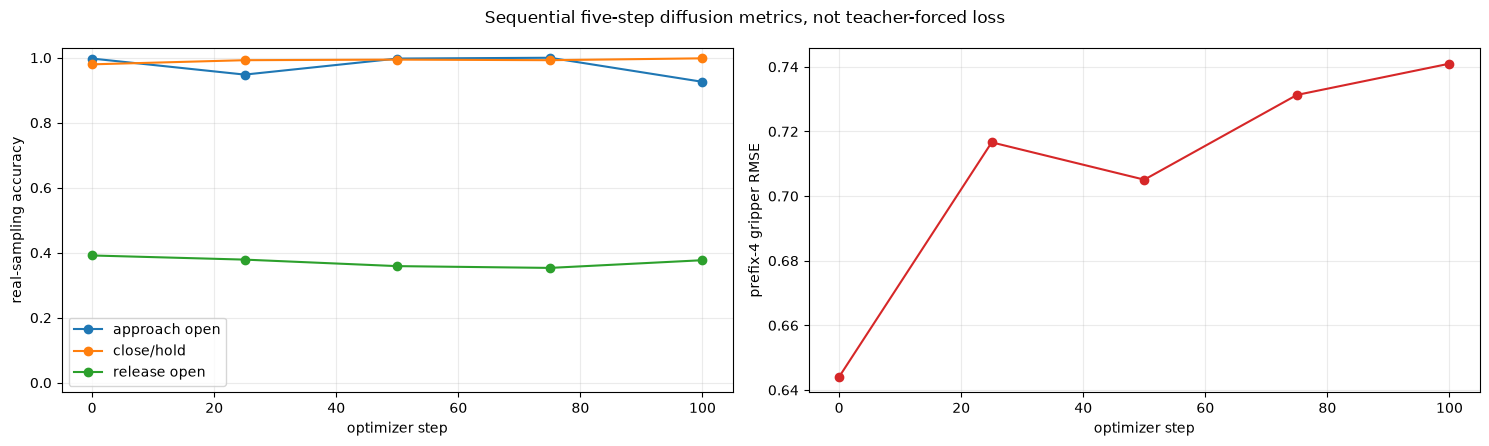

In [4]:
sampling_events = [row for row in report['history'] if 'real_sampling' in row]
steps = [row['step'] for row in sampling_events]
release_accuracy = [row['real_sampling']['gripper_phase']['release_open']['accuracy'] for row in sampling_events]
hold_accuracy = [row['real_sampling']['gripper_phase']['close_hold']['accuracy'] for row in sampling_events]
approach_accuracy = [row['real_sampling']['gripper_phase']['approach_open']['accuracy'] for row in sampling_events]
h4_gripper_rmse = [row['real_sampling']['horizon_rmse']['4']['gripper_rmse'] for row in sampling_events]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(steps, approach_accuracy, marker='o', label='approach open')
axes[0].plot(steps, hold_accuracy, marker='o', label='close/hold')
axes[0].plot(steps, release_accuracy, marker='o', label='release open')
axes[0].set_ylim(-.03, 1.03); axes[0].set_xlabel('optimizer step'); axes[0].set_ylabel('real-sampling accuracy'); axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].plot(steps, h4_gripper_rmse, marker='o', color='tab:red')
axes[1].set_xlabel('optimizer step'); axes[1].set_ylabel('prefix-4 gripper RMSE'); axes[1].grid(alpha=.25)
fig.suptitle('Sequential five-step diffusion metrics, not teacher-forced loss')
plt.tight_layout()

## 2. Verify the raw demonstration and cached release mask

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'samples': 148,
 'release_audit': {'episodes': 1,
  'episodes_with_release': 1,
  'release_targets': 1280},
 'raw_transitions': [42, 128]}

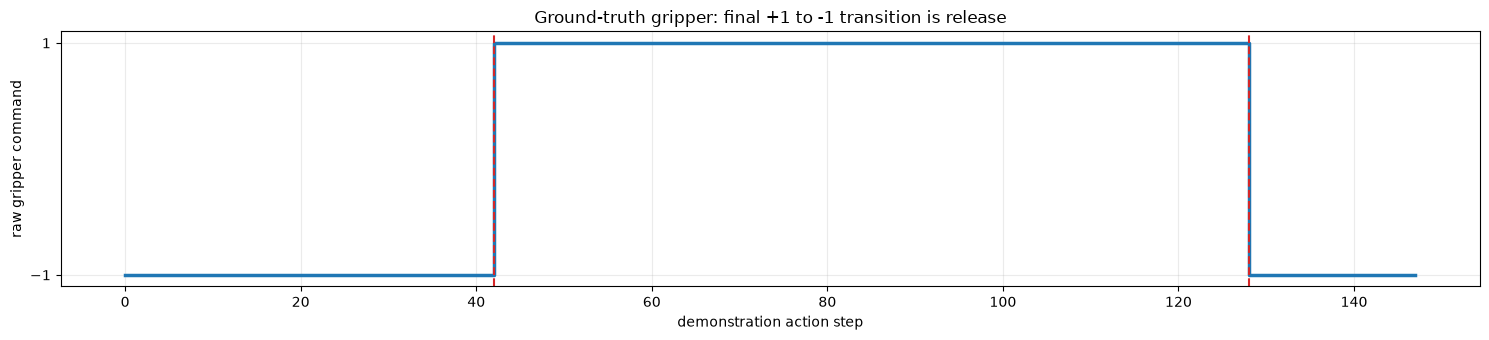

In [5]:
from thinkflow_rdt.data import CachedFeatureDataset, ONLINE_SIGLIP_REQUIRED_KEYS
from overfit_libero_cached import build_gripper_release_masks
dataset = CachedFeatureDataset(manifest_path, required_keys=ONLINE_SIGLIP_REQUIRED_KEYS)
training_indices = [int(i) for i in report['configuration']['sample_indices']]
samples = [dataset[i] for i in training_indices]
release_masks, release_audit = build_gripper_release_masks(samples, horizon=64)
steps_by_position = np.asarray([int(sample['step_idx']) for sample in samples])
assert len(set(str(sample['episode_id']) for sample in samples)) == 1
with h5py.File(DEMO_PATH, 'r') as handle:
    raw_actions = np.asarray(handle['data'][DEMO_NAME]['actions'], dtype=np.float32)[:, :7]
raw_gripper = raw_actions[:, 6]
transitions = np.flatnonzero(np.signbit(raw_gripper[1:]) != np.signbit(raw_gripper[:-1])) + 1
display({'samples': len(samples), 'release_audit': release_audit, 'raw_transitions': transitions.tolist()})
plt.figure(figsize=(15, 3.5))
plt.step(np.arange(len(raw_gripper)), raw_gripper, where='post', linewidth=2.5)
for transition in transitions: plt.axvline(transition, color='tab:red', linestyle='--')
plt.yticks([-1, 1]); plt.xlabel('demonstration action step'); plt.ylabel('raw gripper command'); plt.title('Ground-truth gripper: final +1 to -1 transition is release'); plt.grid(alpha=.25); plt.tight_layout()
assert transitions[-1] == 128
assert release_masks[steps_by_position == 128, 0].item()

## 3. Inspect final saved sequential samples and executed-prefix metrics

In [6]:
snapshots = torch.load(SAMPLES_PATH, map_location='cpu', weights_only=True)
snapshot_name = sorted(snapshots)[-1]
snapshot = snapshots[snapshot_name]
audit_indices = [int(i) for i in report['configuration'].get('real_sampling_audit_indices', training_indices)]
audit_steps = np.asarray([int(dataset[i]['step_idx']) for i in audit_indices])
repeat_count = len(snapshot['prediction_10d']) // len(audit_indices)
prediction = snapshot['prediction_10d'][:len(audit_indices)].float().numpy()
target = snapshot['target_10d'][:len(audit_indices)].float().numpy()
time_mask = snapshot['time_mask'][:len(audit_indices)].bool().numpy()
release_mask = snapshot.get('gripper_release_mask')
if release_mask is None:
    position_by_dataset_index = {index: position for position, index in enumerate(training_indices)}
    release_mask = torch.stack([release_masks[position_by_dataset_index[i]] for i in audit_indices])
else:
    release_mask = release_mask[:len(audit_indices)]
release_mask = release_mask.bool().numpy()
print('Snapshot:', snapshot_name, 'audit conditions:', len(audit_indices), 'repeats:', repeat_count)

def phase_metrics(pred, truth, valid, release, horizon):
    h = min(horizon, pred.shape[1]); valid = valid[:, :h]; release = release[:, :h] & valid
    pred_positive = pred[:, :h, 9] >= 0; truth_positive = truth[:, :h, 9] >= 0
    hold = valid & truth_positive; approach = valid & ~truth_positive & ~release
    def accuracy(mask): return None if not mask.any() else float(np.mean(pred_positive[mask] == truth_positive[mask]))
    return {'horizon': h, 'approach_open': accuracy(approach), 'close_hold': accuracy(hold), 'release_open': accuracy(release), 'release_commands': int(release.sum())}
display([phase_metrics(prediction, target, time_mask, release_mask, h) for h in (1, 4, 8, 64)])

Snapshot: step_000100 audit conditions: 64 repeats: 1


[{'horizon': 1,
  'approach_open': 1.0,
  'close_hold': 1.0,
  'release_open': 0.0,
  'release_commands': 9},
 {'horizon': 4,
  'approach_open': 0.9859154929577465,
  'close_hold': 1.0,
  'release_open': 0.0,
  'release_commands': 35},
 {'horizon': 8,
  'approach_open': 0.9777777777777777,
  'close_hold': 1.0,
  'release_open': 0.0,
  'release_commands': 69},
 {'horizon': 64,
  'approach_open': 0.9259259259259259,
  'close_hold': 0.998237108858528,
  'release_open': 0.3770491803278688,
  'release_commands': 549}]

[{'horizon': 4,
  'best_threshold': 0.3745484374999999,
  'best_balanced_accuracy': 0.8349056603773585,
  'accuracy_at_zero': 0.857707509881423},
 {'horizon': 64,
  'best_threshold': 0.9733968749999999,
  'best_balanced_accuracy': 0.8234528736141948,
  'accuracy_at_zero': 0.883338504498914}]

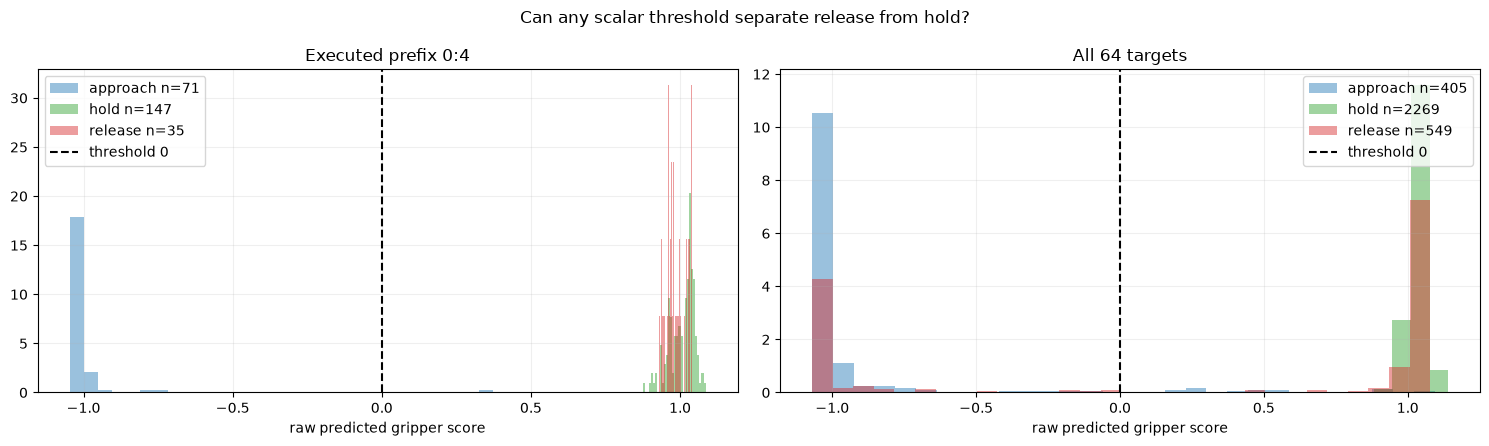

In [7]:
def threshold_audit(horizon):
    h = min(horizon, prediction.shape[1]); valid = time_mask[:, :h]
    scores = prediction[:, :h, 9][valid]; labels = target[:, :h, 9][valid] >= 0
    phases = np.where(release_mask[:, :h][valid], 'release', np.where(labels, 'hold', 'approach'))
    thresholds = np.linspace(float(scores.min()) - .05, float(scores.max()) + .05, 1001)
    balanced = []
    for threshold in thresholds:
        pred_positive = scores >= threshold
        balanced.append(.5 * (np.mean(pred_positive[labels]) + np.mean(~pred_positive[~labels])))
    best = int(np.nanargmax(balanced))
    return scores, phases, {'horizon': h, 'best_threshold': float(thresholds[best]), 'best_balanced_accuracy': float(balanced[best]), 'accuracy_at_zero': float(np.mean((scores >= 0) == labels))}

scores4, phases4, threshold4 = threshold_audit(4)
scores64, phases64, threshold64 = threshold_audit(64)
display([threshold4, threshold64])
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, scores, phases, title in ((axes[0], scores4, phases4, 'Executed prefix 0:4'), (axes[1], scores64, phases64, 'All 64 targets')):
    for phase, color in [('approach','tab:blue'), ('hold','tab:green'), ('release','tab:red')]:
        values = scores[phases == phase]
        if len(values): ax.hist(values, bins=30, alpha=.45, density=True, color=color, label=f'{phase} n={len(values)}')
    ax.axvline(0, color='black', linestyle='--', label='threshold 0'); ax.set_xlabel('raw predicted gripper score'); ax.set_title(title); ax.legend(); ax.grid(alpha=.2)
fig.suptitle('Can any scalar threshold separate release from hold?'); plt.tight_layout()

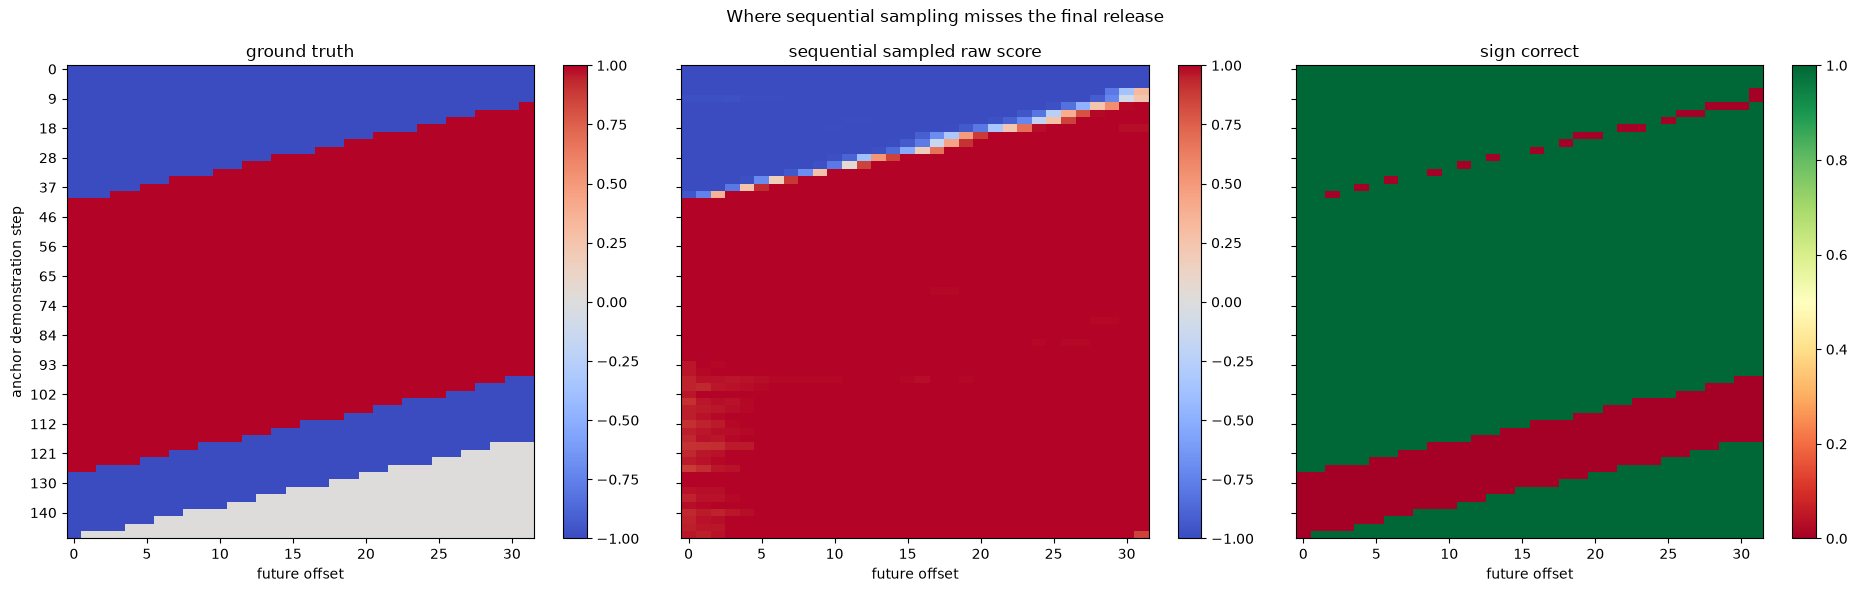

In [8]:
order = np.argsort(audit_steps); max_h = min(32, prediction.shape[1])
fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharey=True)
for ax, values, title, cmap, vmin, vmax in (
    (axes[0], target[order, :max_h, 9], 'ground truth', 'coolwarm', -1, 1),
    (axes[1], prediction[order, :max_h, 9], 'sequential sampled raw score', 'coolwarm', -1, 1),
    (axes[2], (prediction[order, :max_h, 9] >= 0) == (target[order, :max_h, 9] >= 0), 'sign correct', 'RdYlGn', 0, 1),
):
    image = ax.imshow(values, aspect='auto', interpolation='nearest', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.set_xlabel('future offset'); plt.colorbar(image, ax=ax)
axes[0].set_yticks(np.arange(len(order))[::4], audit_steps[order][::4]); axes[0].set_ylabel('anchor demonstration step')
fig.suptitle('Where sequential sampling misses the final release'); plt.tight_layout()

## 4. Detect a fixed horizon-position gripper template

In [20]:
import pandas as pd

,future_offset,release_accuracy,median_raw_gripper_score
0,0,0.000000,0.964844
1,1,0.000000,0.976562
2,4,0.000000,1.019531
3,8,0.000000,1.050781
4,16,0.000000,1.054688
5,32,0.000000,1.050781
6,38,0.222222,0.914062
7,39,0.375000,0.662109
8,40,0.777778,-0.108398
9,41,0.875000,-0.880859


First offset with >=50% release accuracy: 40
First offset with 100% release accuracy: 42


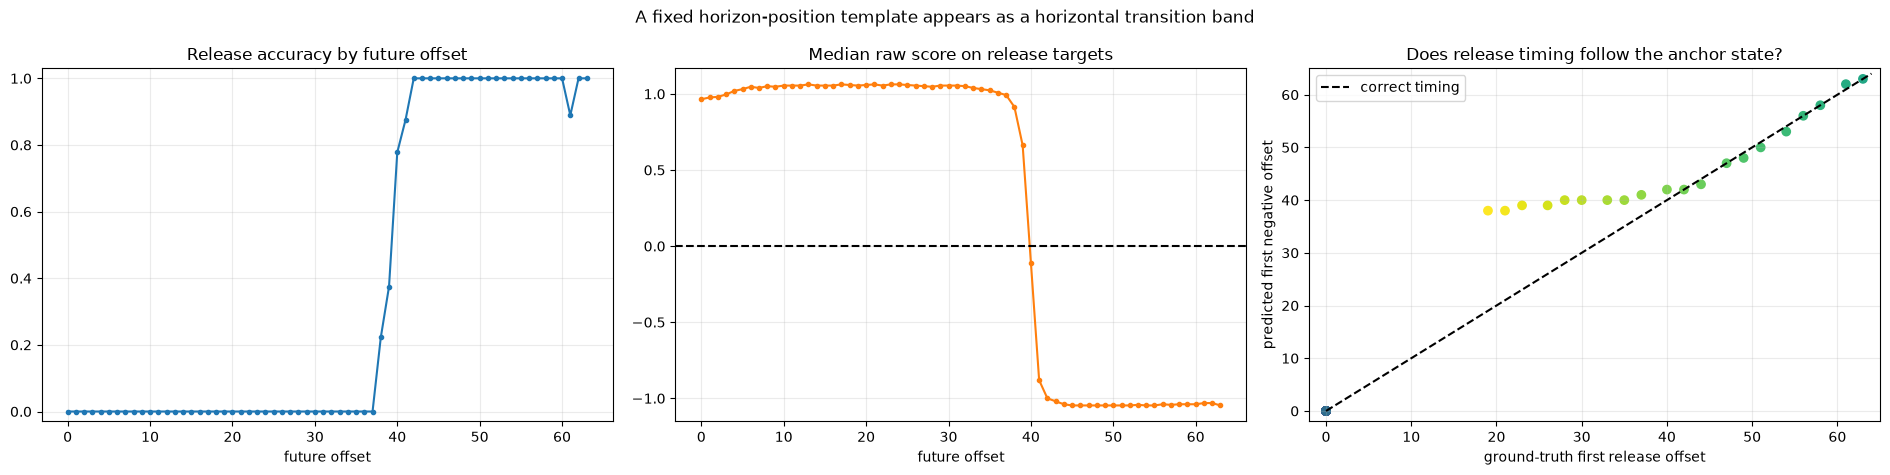

In [21]:
release_accuracy_by_offset, release_score_by_offset = [], []
for offset in range(prediction.shape[1]):
    mask = release_mask[:, offset] & time_mask[:, offset]
    release_accuracy_by_offset.append(np.nan if not mask.any() else float(np.mean(prediction[mask, offset, 9] < 0)))
    release_score_by_offset.append(np.nan if not mask.any() else float(np.median(prediction[mask, offset, 9])))

def first_release_offset(values, valid):
    negative = np.flatnonzero((values < 0) & valid)
    return np.nan if not len(negative) else float(negative[0])
target_release_offsets = np.asarray([first_release_offset(target[row, :, 9], time_mask[row]) for row in range(len(target))])
predicted_release_offsets = np.asarray([first_release_offset(prediction[row, :, 9], time_mask[row]) for row in range(len(prediction))])
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
axes[0].plot(release_accuracy_by_offset, marker='o', markersize=3); axes[0].set_ylim(-.03, 1.03); axes[0].set_title('Release accuracy by future offset'); axes[0].set_xlabel('future offset'); axes[0].grid(alpha=.25)
axes[1].plot(release_score_by_offset, marker='o', markersize=3, color='tab:orange'); axes[1].axhline(0, color='black', linestyle='--'); axes[1].set_title('Median raw score on release targets'); axes[1].set_xlabel('future offset'); axes[1].grid(alpha=.25)
finite = np.isfinite(target_release_offsets)
axes[2].scatter(target_release_offsets[finite], predicted_release_offsets[finite], c=audit_steps[finite], cmap='viridis')
axes[2].plot([0, 64], [0, 64], color='black', linestyle='--', label='correct timing'); axes[2].set_xlim(-2, 65); axes[2].set_ylim(-2, 65); axes[2].set_xlabel('ground-truth first release offset'); axes[2].set_ylabel('predicted first negative offset'); axes[2].set_title('Does release timing follow the anchor state?'); axes[2].legend(); axes[2].grid(alpha=.25)
fig.suptitle('A fixed horizon-position template appears as a horizontal transition band'); plt.tight_layout()

summary_offsets = [offset for offset in (0, 1, 4, 8, 16, 32, 38, 39, 40, 41, 42, 48, 63) if offset < len(release_accuracy_by_offset)]
display(pd.DataFrame({
    'future_offset': summary_offsets,
    'release_accuracy': [release_accuracy_by_offset[offset] for offset in summary_offsets],
    'median_raw_gripper_score': [release_score_by_offset[offset] for offset in summary_offsets],
}))
finite_accuracy = np.asarray(release_accuracy_by_offset, dtype=float)
above_half = np.flatnonzero(np.isfinite(finite_accuracy) & (finite_accuracy >= 0.5))
perfect = np.flatnonzero(np.isfinite(finite_accuracy) & (finite_accuracy >= 1.0))
print('First offset with >=50% release accuracy:', None if not len(above_half) else int(above_half[0]))
print('First offset with 100% release accuracy:', None if not len(perfect) else int(perfect[0]))

## 5. Load the final model and trace the actual five-call solver path

This is the expensive cell. It selects anchor steps spanning approach, grasp, hold, and release, computes their SigLIP tokens once, and loads RDT-1B.

In [9]:
from thinkflow_rdt.checkpoint import load_trainable_artifact
from thinkflow_rdt.config import load_config
from thinkflow_rdt.model import SFTConditionedRDT
from overfit_libero_cached import move_tensors, prepare_fixed_feature_batches
if not torch.cuda.is_available(): raise RuntimeError('CUDA is required for the trace')
device = torch.device('cuda')
selected_steps = [0, 20, 40, 41, 42, 60, 100, 120, 124, 125, 126, 127, 128, 129, 135, 147]
sample_by_step = {int(sample['step_idx']): sample for sample in samples}
selected_samples = [sample_by_step[step] for step in selected_steps]
cfg = load_config(CONFIG_PATH)
cache_metadata = json.loads((CACHE_ROOT / 'precompute_metadata.json').read_text())
fixed_batches = prepare_fixed_feature_batches(selected_samples, cfg=cfg, batch_size=len(selected_samples), device=device, siglip_model_id=cache_metadata['siglip_model_id'], siglip_fallback_model_id='google/siglip-so400m-patch14-384')
cpu_batch = fixed_batches[0]; policy_batch = move_tensors(cpu_batch, device)
model = SFTConditionedRDT(cfg, load_pretrained=True, base_artifact=str(BASE_ARTIFACT))
load_trainable_artifact(model, ARTIFACT_PATH, trainable=False)
model.to(device).eval()
print({'mask_noisy_gripper_input': model.mask_noisy_gripper_input, 'inference_steps': model.runner.num_inference_timesteps, 'selected_steps': selected_steps})

Loading weights: 100%|██████████| 448/448 [00:00<00:00, 1211.00it/s]
[transformers] SiglipVisionModel LOAD REPORT from: google/siglip-so400m-patch14-384
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...26}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm2.

Diffusion params: 1.217850e+09
Diffusion params: 1.228320e+09
{'mask_noisy_gripper_input': True, 'inference_steps': 5, 'selected_steps': [0, 20, 40, 41, 42, 60, 100, 120, 124, 125, 126, 127, 128, 129, 135, 147]}


In [10]:
sampling_x0_trace, solver_trace = [], []
scheduler = model.runner.noise_scheduler_sample
original_scheduler_step = scheduler.step
def capture_x0(_module, _inputs, output): sampling_x0_trace.append(output.detach().float().cpu())
def capture_solver(*args, **kwargs):
    result = original_scheduler_step(*args, **kwargs); solver_trace.append(result.prev_sample.detach().float().cpu()); return result
hook = model.runner.model.register_forward_hook(capture_x0); scheduler.step = capture_solver
torch.manual_seed(42); torch.cuda.manual_seed_all(42)
try:
    with torch.inference_mode(): returned_actions = model.sample_actions(policy_batch).float().cpu()
finally:
    hook.remove(); scheduler.step = original_scheduler_step
sampling_x0_trace = torch.stack(sampling_x0_trace)
solver_trace = torch.stack(solver_trace)
sampling_timesteps = scheduler.timesteps.detach().cpu().numpy().astype(int)
assert len(sampling_timesteps) == len(sampling_x0_trace) == len(solver_trace)
print('Actual sequential solver timesteps:', sampling_timesteps.tolist())
print('Final solver versus final clean-x0 gripper max difference:', float((solver_trace[-1, ..., 9] - sampling_x0_trace[-1, ..., 9]).abs().max()))
print('Returned versus final clean-x0 gripper max difference:', float((returned_actions[..., 9] - sampling_x0_trace[-1, ..., 9]).abs().max()))

Actual sequential solver timesteps: [999, 799, 599, 400, 200]
Final solver versus final clean-x0 gripper max difference: 0.0
Returned versus final clean-x0 gripper max difference: 0.0


## 6. Compare teacher-forced x0 with on-policy sequential x0

In [11]:
teacher_forced_trace = []
for trace_index, timestep in enumerate(sampling_timesteps):
    batch = move_tensors(cpu_batch, device)
    generator = torch.Generator(device='cpu').manual_seed(10_000 + trace_index)
    batch['diffusion_timesteps'] = torch.full((len(selected_steps),), int(timestep), dtype=torch.long, device=device)
    batch['diffusion_noise'] = torch.randn(batch['actions'].shape, generator=generator).to(device)
    batch['return_denoising_prediction'] = True
    with torch.inference_mode(): teacher_forced_trace.append(model(batch)['denoising_prediction'].float().cpu())
teacher_forced_trace = torch.stack(teacher_forced_trace)
target_selected = cpu_batch['actions'].float()
release_selected, _ = build_gripper_release_masks(selected_samples, horizon=64)
valid_selected = cpu_batch['action_time_mask'].bool()

def release_accuracy_tensor(values, horizon=64):
    h = min(horizon, values.shape[1]); mask = release_selected[:, :h] & valid_selected[:, :h]
    return None if not mask.any() else float(((values[:, :h, 9] >= 0) == (target_selected[:, :h, 9] >= 0))[mask].float().mean())
rows = []
for index, timestep in enumerate(sampling_timesteps):
    rows.append({'solver_timestep': int(timestep), 'teacher_forced_release_accuracy': release_accuracy_tensor(teacher_forced_trace[index]), 'sequential_x0_release_accuracy': release_accuracy_tensor(sampling_x0_trace[index])})
rows.append({'solver_timestep': 'returned', 'teacher_forced_release_accuracy': None, 'sequential_x0_release_accuracy': release_accuracy_tensor(returned_actions)})
display(rows)

[{'solver_timestep': 999,
  'teacher_forced_release_accuracy': 1.0,
  'sequential_x0_release_accuracy': 0.04624277353286743},
 {'solver_timestep': 799,
  'teacher_forced_release_accuracy': 1.0,
  'sequential_x0_release_accuracy': 0.04624277353286743},
 {'solver_timestep': 599,
  'teacher_forced_release_accuracy': 0.9942196607589722,
  'sequential_x0_release_accuracy': 0.05202312022447586},
 {'solver_timestep': 400,
  'teacher_forced_release_accuracy': 1.0,
  'sequential_x0_release_accuracy': 0.05202312022447586},
 {'solver_timestep': 200,
  'teacher_forced_release_accuracy': 1.0,
  'sequential_x0_release_accuracy': 0.05202312022447586},
 {'solver_timestep': 'returned',
  'teacher_forced_release_accuracy': None,
  'sequential_x0_release_accuracy': 0.05202312022447586}]

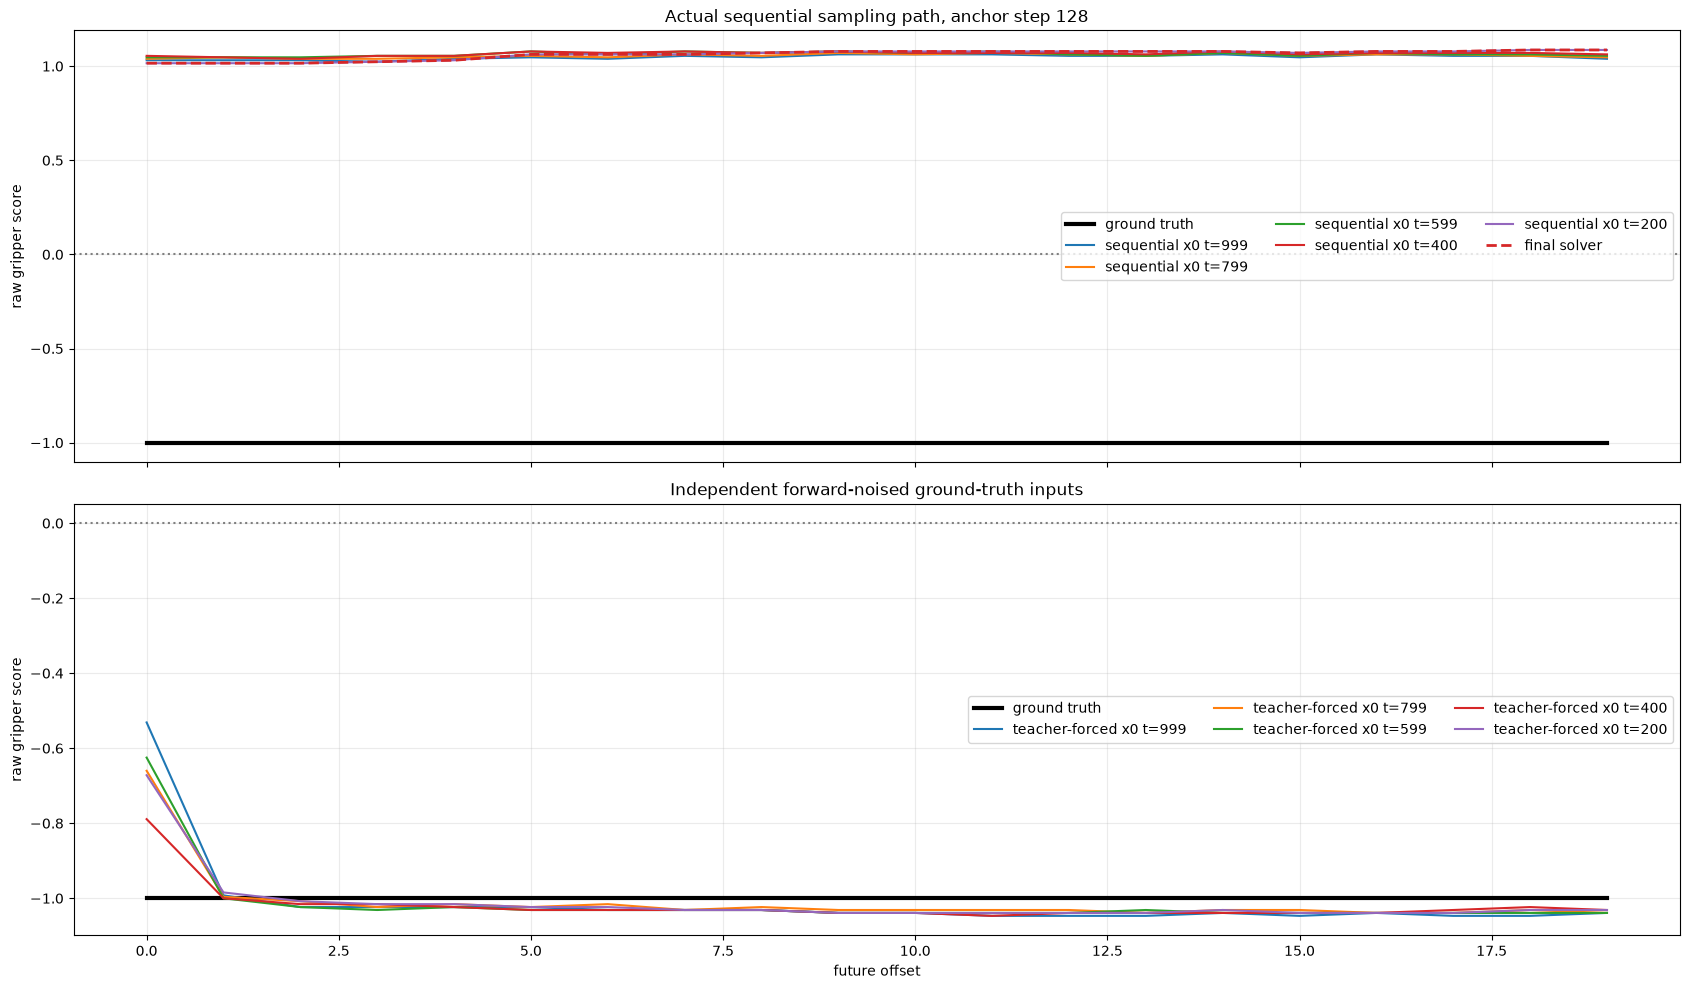

In [12]:
anchor_row = selected_steps.index(128); valid_count = int(valid_selected[anchor_row].sum()); offsets = np.arange(valid_count)
fig, axes = plt.subplots(2, 1, figsize=(17, 10), sharex=True)
axes[0].step(offsets, target_selected[anchor_row, :valid_count, 9], where='post', color='black', linewidth=3, label='ground truth')
for index, timestep in enumerate(sampling_timesteps): axes[0].plot(offsets, sampling_x0_trace[index, anchor_row, :valid_count, 9], label=f'sequential x0 t={timestep}')
axes[0].plot(offsets, solver_trace[-1, anchor_row, :valid_count, 9], color='tab:red', linestyle='--', linewidth=2, label='final solver')
axes[0].set_title('Actual sequential sampling path, anchor step 128'); axes[0].legend(ncol=3); axes[0].grid(alpha=.25)
axes[1].step(offsets, target_selected[anchor_row, :valid_count, 9], where='post', color='black', linewidth=3, label='ground truth')
for index, timestep in enumerate(sampling_timesteps): axes[1].plot(offsets, teacher_forced_trace[index, anchor_row, :valid_count, 9], label=f'teacher-forced x0 t={timestep}')
axes[1].set_title('Independent forward-noised ground-truth inputs'); axes[1].set_xlabel('future offset'); axes[1].legend(ncol=3); axes[1].grid(alpha=.25)
for ax in axes: ax.axhline(0, color='grey', linestyle=':'); ax.set_ylabel('raw gripper score')
plt.tight_layout()

## 7. Shortcut ablation: remove or shuffle the noisy motion trajectory

The gripper input is already zero, but teacher-forced `dx/dy/dz/rotation6D` still comes from the correct future action chunk. This ablation tests whether release classification depends on that privileged motion trajectory.

[{'input_mode': 'teacher_forced',
  'release_accuracy': 1.0,
  'prefix4_release_accuracy': 1.0},
 {'input_mode': 'shuffle_action_tokens_between_conditions',
  'release_accuracy': 0.9942196607589722,
  'prefix4_release_accuracy': 1.0},
 {'input_mode': 'zero_all_action_tokens',
  'release_accuracy': 0.9942196607589722,
  'prefix4_release_accuracy': 1.0}]

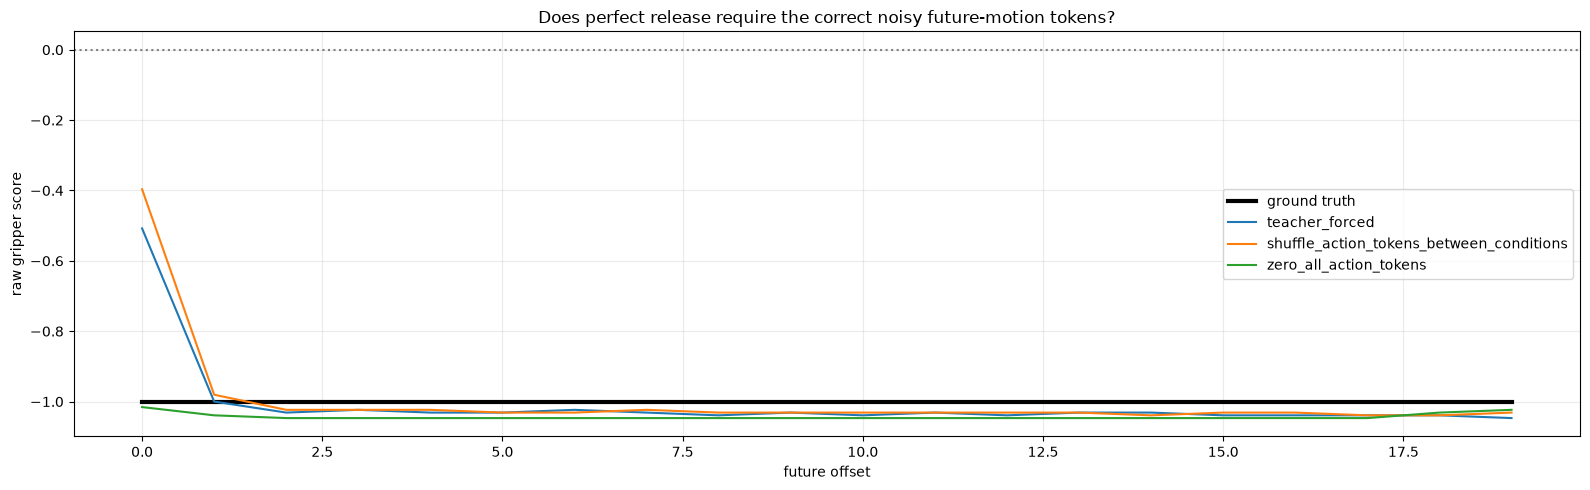

In [13]:
original_adapt_actions = model._adapt_actions
def run_ablation(mode, timestep=999):
    batch = move_tensors(cpu_batch, device)
    generator = torch.Generator(device='cpu').manual_seed(777)
    batch['diffusion_timesteps'] = torch.full((len(selected_steps),), timestep, dtype=torch.long, device=device)
    batch['diffusion_noise'] = torch.randn(batch['actions'].shape, generator=generator).to(device)
    batch['return_denoising_prediction'] = True
    if mode == 'zero_all_action_tokens':
        def replacement(_self, actions, action_mask): return original_adapt_actions(torch.zeros_like(actions), action_mask)
    elif mode == 'shuffle_action_tokens_between_conditions':
        def replacement(_self, actions, action_mask): return original_adapt_actions(torch.roll(actions, 1, 0), action_mask)
    elif mode == 'teacher_forced':
        replacement = None
    else: raise ValueError(mode)
    if replacement is not None: model._adapt_actions = MethodType(replacement, model)
    try:
        with torch.inference_mode(): output = model(batch)['denoising_prediction'].float().cpu()
    finally:
        model._adapt_actions = original_adapt_actions
    return output
ablation_outputs = {mode: run_ablation(mode) for mode in ('teacher_forced', 'shuffle_action_tokens_between_conditions', 'zero_all_action_tokens')}
display([{'input_mode': mode, 'release_accuracy': release_accuracy_tensor(output), 'prefix4_release_accuracy': release_accuracy_tensor(output, 4)} for mode, output in ablation_outputs.items()])
fig, ax = plt.subplots(figsize=(16, 5))
ax.step(offsets, target_selected[anchor_row, :valid_count, 9], where='post', color='black', linewidth=3, label='ground truth')
for mode, output in ablation_outputs.items(): ax.plot(offsets, output[anchor_row, :valid_count, 9], label=mode)
ax.axhline(0, color='grey', linestyle=':'); ax.set_xlabel('future offset'); ax.set_ylabel('raw gripper score'); ax.set_title('Does perfect release require the correct noisy future-motion tokens?'); ax.legend(); ax.grid(alpha=.25); plt.tight_layout()

## 8. Temporal-mask leakage ablation

Near the end of the demonstration, training marks the suffix beyond step 147 invalid and zeros it. Normal sampling has no episode-end signal and treats all 64 tokens as valid. The following 2×2 ablation separates action values from the temporal mask.

In [14]:
original_adapt_actions = model._adapt_actions
fixed_random = torch.randn(cpu_batch['actions'].shape, generator=torch.Generator().manual_seed(4242)).to(device=device, dtype=policy_batch['state'].dtype)
training_token_mask = (cpu_batch['action_dim_mask'].unsqueeze(1) * cpu_batch['action_time_mask'].unsqueeze(-1)).to(device=device, dtype=policy_batch['state'].dtype)
full_token_mask = cpu_batch['action_dim_mask'].unsqueeze(1).expand_as(cpu_batch['actions']).to(device=device, dtype=policy_batch['state'].dtype)

def run_value_mask_ablation(value_mode, mask_mode, timestep=999):
    batch = move_tensors(cpu_batch, device)
    batch['diffusion_timesteps'] = torch.full((len(selected_steps),), timestep, dtype=torch.long, device=device)
    batch['diffusion_noise'] = torch.randn(batch['actions'].shape, generator=torch.Generator().manual_seed(999)).to(device)
    batch['return_denoising_prediction'] = True
    chosen_mask = training_token_mask if mask_mode == 'training_time_mask' else full_token_mask
    def replacement(_self, _actions, _action_mask):
        values = torch.zeros_like(_actions) if value_mode == 'zeros' else fixed_random.to(_actions.dtype)
        values = values.clone(); values[..., 9] = 0
        values = values * chosen_mask.to(values.dtype)
        return original_adapt_actions(values, chosen_mask.to(values.dtype))
    model._adapt_actions = MethodType(replacement, model)
    try:
        with torch.inference_mode(): return model(batch)['denoising_prediction'].float().cpu()
    finally:
        model._adapt_actions = original_adapt_actions

mask_ablation_outputs = {(values, mask): run_value_mask_ablation(values, mask) for values in ('zeros', 'random') for mask in ('training_time_mask', 'full_64_mask')}
display([{'action_values': values, 'temporal_mask': mask, 'release_accuracy': release_accuracy_tensor(output), 'prefix4_release_accuracy': release_accuracy_tensor(output, 4)} for (values, mask), output in mask_ablation_outputs.items()])

[{'action_values': 'zeros',
  'temporal_mask': 'training_time_mask',
  'release_accuracy': 0.9942196607589722,
  'prefix4_release_accuracy': 1.0},
 {'action_values': 'zeros',
  'temporal_mask': 'full_64_mask',
  'release_accuracy': 0.04624277353286743,
  'prefix4_release_accuracy': 0.0},
 {'action_values': 'random',
  'temporal_mask': 'training_time_mask',
  'release_accuracy': 1.0,
  'prefix4_release_accuracy': 1.0},
 {'action_values': 'random',
  'temporal_mask': 'full_64_mask',
  'release_accuracy': 0.05202312022447586,
  'prefix4_release_accuracy': 0.0}]

In [15]:
# Counterfactual sequential sampling: apply the demonstration's training-time
# horizon mask at every solver call. This is diagnostic only; deployment does
# not know when an episode should end.
original_adapt_actions = model._adapt_actions
def masked_sampling_adaptor(_self, actions, _action_mask):
    mask = training_token_mask.to(device=actions.device, dtype=actions.dtype)
    return original_adapt_actions(actions * mask, mask)
model._adapt_actions = MethodType(masked_sampling_adaptor, model)
torch.manual_seed(42); torch.cuda.manual_seed_all(42)
try:
    with torch.inference_mode(): masked_sampling_returned = model.sample_actions(policy_batch).float().cpu()
finally:
    model._adapt_actions = original_adapt_actions
display({'normal_sequential_release_accuracy': release_accuracy_tensor(returned_actions), 'counterfactual_training_mask_release_accuracy': release_accuracy_tensor(masked_sampling_returned), 'normal_prefix4_release_accuracy': release_accuracy_tensor(returned_actions, 4), 'counterfactual_prefix4_release_accuracy': release_accuracy_tensor(masked_sampling_returned, 4)})

{'normal_sequential_release_accuracy': 0.05202312022447586,
 'counterfactual_training_mask_release_accuracy': 1.0,
 'normal_prefix4_release_accuracy': 0.0,
 'counterfactual_prefix4_release_accuracy': 1.0}

## Interpretation

- If teacher-forced x0 is correct but sequential x0 is wrong at the first `t=999` call, the conditioning alone has not learned release.
- If `t=999` is correct and later sequential calls become wrong, generated motion tokens pull the gripper off the correct denoising manifold.
- If shuffling or zeroing action tokens collapses teacher-forced release accuracy, the 100% diagnostic was using privileged forward-noised ground-truth motion, not robust visual/state phase recognition.
- If release and hold raw-score histograms overlap, threshold tuning cannot solve the checkpoint.
- If the training-time mask restores sequential release, the policy learned the padded end-of-demo mask as its release cue. Training must use a full 64-token terminal continuation rather than an inference-unavailable suffix mask.
- Prefix-4 phase accuracy is the rollout-relevant measure because offsets 4–63 are discarded at every replan.

In [ ]:
# Cleanup after all plots.
if 'model' in globals():
    del model, policy_batch, fixed_batches
    gc.collect(); torch.cuda.empty_cache(); print('Released RDT and cached GPU tensors')